# Clasificador de rango etario 

### Banco de datos UTKFace

Clasificación multiclase en 5 clases a partir de fotos de rostros. Armamos el mismo modelo en PyTorch y en TensorFlow/Keras para poder comparar los dos frameworks.

Rangos que usamos:

| Clase | Rango | Etiqueta |
|---|---|---|
| 0 | 0-12 | niño |
| 1 | 13-19 | adolescente |
| 2 | 20-35 | joven |
| 3 | 36-59 | adulto |
| 4 | 60+ | viejo |


## Notebook de resultados: banco UTKFace completo (desbalanceado)

Este notebook se queda con los resultados de la corrida de referencia (tablas, gráficos, matrices de confusión y curvas). Mejor no re-ejecutarlo si queremos conservar estos números.

El banco es UTKFace completo, tal cual viene del dataset original:
- Carpeta: `./UTKFace_data/UTKFace`
- Imágenes válidas: 23.705 (de 23.708 archivos; 3 quedaron fuera por tener el nombre mal formado)
- Queda bastante desbalanceado:

| Clase | Etiqueta | N° imágenes |
|---|---|---|
| 0 | niño (0-12) | 3.413 |
| 1 | adolescente (13-19) | 1.180 |
| 2 | joven (20-35) | 10.514 |
| 3 | adulto (36-59) | 5.910 |
| 4 | viejo (60+) | 2.688 |

Config: IMG_SIZE=64, BATCH_SIZE=32, SEED=42, split estratificado 70/15/15 (Train 16.593, Val 3.556, Test 3.556), 10 épocas, CNN de 3 conv + 2 FC, Adam lr=1e-3, corrido en CPU.

En resumen: PyTorch llegó a val_acc ≈ 0.74 y Keras a ≈ 0.72. El desbalance castiga sobre todo a 'adolescente' y 'viejo' (las clases más chicas), que terminan confundiéndose con 'joven' y 'adulto'.

Para comparar contra la versión balanceada, mira `clasificador_edad_utkface.ipynb` (1.180 imágenes por clase).


## 0. Descargar el dataset (UTKFace)

**Opción A: Kaggle API (la más cómoda)**

```bash
pip install kaggle
# 1. Crea una cuenta en kaggle.com si no tienes
# 2. Anda a kaggle.com/settings -> API -> "Create New Token" (baja el kaggle.json)
# 3. Deja kaggle.json en ~/.kaggle/kaggle.json (Linux/Mac) o C:\Users\<usuario>\.kaggle\kaggle.json (Windows)

kaggle datasets download -d jangedoo/utkface-new
unzip utkface-new.zip -d ./UTKFace_data
```

**Opción B: descarga manual**

1. Anda a https://www.kaggle.com/datasets/jangedoo/utkface-new
2. Baja el .zip (botón Download)
3. Descomprime y deja las imágenes en `./UTKFace_data/UTKFace/` (los .jpg tienen que quedar sueltos ahí, sin subcarpetas extra)

Debería quedar así:
```
UTKFace_data/
  UTKFace/
    1_0_0_20161219140623097.jpg
    2_1_3_20170109150557335.jpg
    ...
```

Cada archivo se llama con el formato `[edad]_[género]_[raza]_[fecha].jpg`. De todo eso, acá solo nos importa la edad.


In [1]:
!pip install pandas matplotlib seaborn scikit-learn torch tensorflow pillow

In [2]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"   # <-- ajusta esta ruta si tu carpeta quedó en otro lugar
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [3]:
# --- Definición de los rangos etarios ---
CLASS_NAMES = ["nino", "adolescente", "joven", "adulto", "viejo"]

def age_to_bucket(age: int) -> int:
    """Convierte una edad entera al índice de clase (0-4) según los rangos definidos."""
    if age <= 12:
        return 0  # nino
    elif age <= 19:
        return 1  # adolescente
    elif age <= 35:
        return 2  # joven
    elif age <= 59:
        return 3  # adulto
    else:
        return 4  # viejo

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

In [4]:
# --- Construcción del dataframe (ruta de imagen + edad + clase) ---
filepaths = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
print(f"Imágenes encontradas: {len(filepaths)}")

records = []
skipped = 0
for fp in filepaths:
    age = parse_age_from_filename(fp)
    if age is None or age > 116:  # 116 es la edad máxima reportada en UTKFace; filtramos basura
        skipped += 1
        continue
    records.append({"filepath": fp, "age": age, "label": age_to_bucket(age)})

df = pd.DataFrame(records)
print(f"Imágenes válidas: {len(df)}  |  Descartadas (nombre mal formado): {skipped}")
df.head()

Imágenes encontradas: 23708
Imágenes válidas: 23705  |  Descartadas (nombre mal formado): 3


,filepath,age,label
0,./UTKFace_data/UTKFace\100_0_0_201701122135009...,100,4
1,./UTKFace_data/UTKFace\100_0_0_201701122152403...,100,4
2,./UTKFace_data/UTKFace\100_1_0_201701101837263...,100,4
3,./UTKFace_data/UTKFace\100_1_0_201701122130019...,100,4
4,./UTKFace_data/UTKFace\100_1_0_201701122133036...,100,4


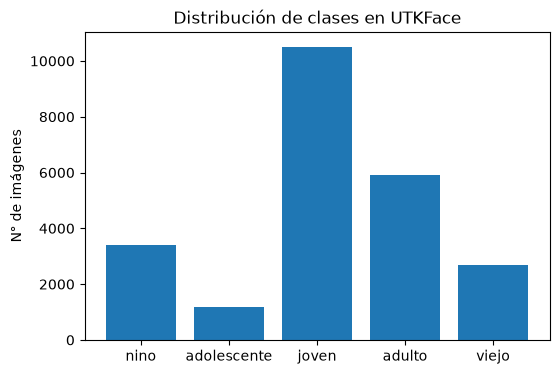

label
0     3413
1     1180
2    10514
3     5910
4     2688
Name: count, dtype: int64


In [5]:
# --- Distribución de clases ---
counts = df["label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar([CLASS_NAMES[i] for i in counts.index], counts.values)
plt.title("Distribución de clases en UTKFace")
plt.ylabel("N° de imágenes")
plt.show()

print(counts)
# Nota: UTKFace suele estar desbalanceado (pocos 'viejo' y 'adolescente').
# Si el desbalance es muy fuerte, considera usar class_weight (Keras) o
# WeightedRandomSampler (PyTorch) más adelante.

In [6]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 16593  |  Val: 3556  |  Test: 3556


## Parte A: PyTorch


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import time
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [8]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [9]:
# --- Entrenamiento (PyTorch) ---
ti_pt = time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

tf_pt = time.time()
t_total_pt = tf_pt - ti_pt
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total_pt:.2f} segundos")

Epoch 1/10 | train_loss=1.0199 train_acc=0.5924 | val_loss=0.8614 val_acc=0.6541
Epoch 2/10 | train_loss=0.8190 train_acc=0.6729 | val_loss=0.8112 val_acc=0.6589
Epoch 3/10 | train_loss=0.7384 train_acc=0.7027 | val_loss=0.7336 val_acc=0.7103
Epoch 4/10 | train_loss=0.6719 train_acc=0.7268 | val_loss=0.7060 val_acc=0.7078
Epoch 5/10 | train_loss=0.6256 train_acc=0.7422 | val_loss=0.6884 val_acc=0.7137
Epoch 6/10 | train_loss=0.5796 train_acc=0.7610 | val_loss=0.6602 val_acc=0.7283
Epoch 7/10 | train_loss=0.5332 train_acc=0.7815 | val_loss=0.7093 val_acc=0.7205
Epoch 8/10 | train_loss=0.4930 train_acc=0.7993 | val_loss=0.7678 val_acc=0.7334
Epoch 9/10 | train_loss=0.4518 train_acc=0.8111 | val_loss=0.7950 val_acc=0.7255
Epoch 10/10 | train_loss=0.4060 train_acc=0.8321 | val_loss=0.7848 val_acc=0.7208

Tiempo total de entrenamiento (PyTorch): 667.33 segundos


              precision    recall  f1-score   support

        nino       0.94      0.89      0.91       512
 adolescente       0.48      0.28      0.35       177
       joven       0.74      0.85      0.79      1577
      adulto       0.59      0.57      0.58       887
       viejo       0.74      0.55      0.63       403

    accuracy                           0.72      3556
   macro avg       0.70      0.63      0.65      3556
weighted avg       0.72      0.72      0.72      3556



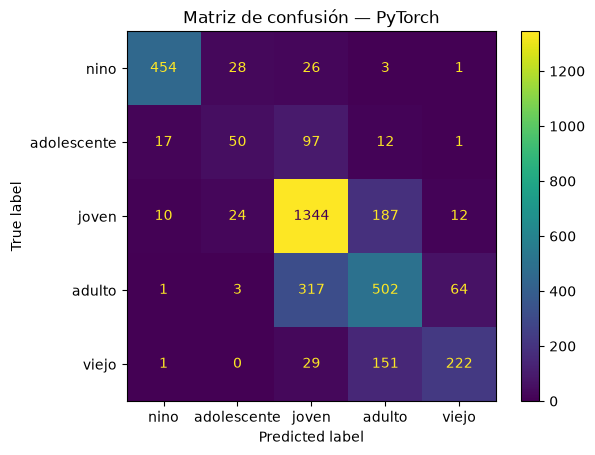

In [10]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — PyTorch")
plt.show()

### Curva ROC — PyTorch

Curva ROC multiclase (One-vs-Rest): cada clase se compara contra el resto. El AUC resume la curva en un número: cercano a **1.0** = excelente separación, **0.5** = equivale al azar. La curva punteada negra es el **micro-promedio** (todas las clases juntas).

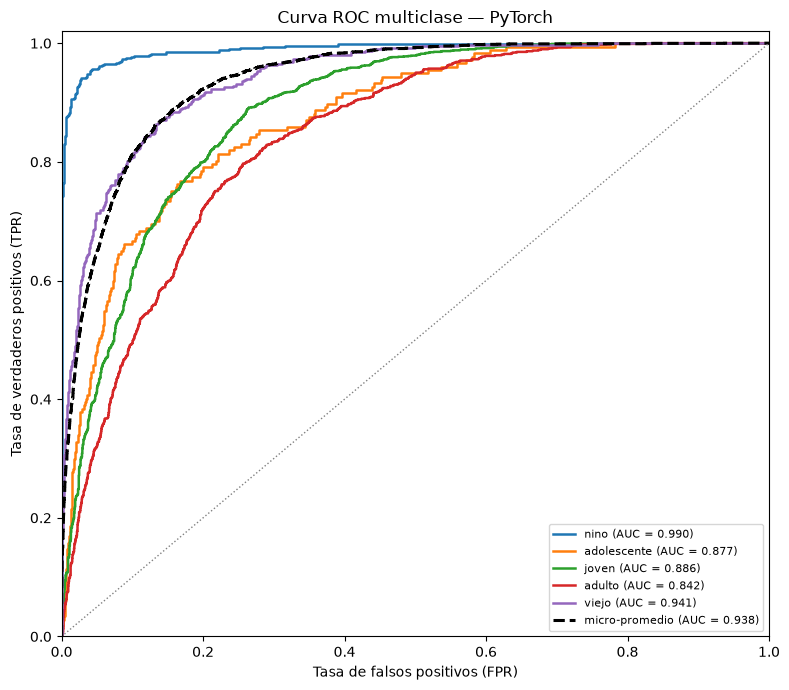

In [11]:
# --- Curva ROC (PyTorch) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Recolectamos las probabilidades (softmax) del modelo sobre el set de test.
model_pt.eval()
probs_pt, y_roc_pt = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        p = F.softmax(model_pt(imgs), dim=1)
        probs_pt.extend(p.cpu().numpy())
        y_roc_pt.extend(labels.numpy())
probs_pt = np.array(probs_pt)
y_roc_pt = np.array(y_roc_pt)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_pt, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_pt[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

# Micro-promedio: junta todas las clases en una sola curva global.
fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_pt.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — PyTorch")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Parte B: TensorFlow / Keras


In [12]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [13]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)
tf2=time.time()
t_total_tf = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total_tf:.2f} segundos")

Epoch 1/10


c:\Users\fsali\Documents\GitHub\frameworks-ia-2026_udd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


519/519 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.5842 - loss: 1.0536 - val_accuracy: 0.6715 - val_loss: 0.8294
Epoch 2/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.6767 - loss: 0.8197 - val_accuracy: 0.6926 - val_loss: 0.7475
Epoch 3/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.7052 - loss: 0.7358 - val_accuracy: 0.6834 - val_loss: 0.7616
Epoch 4/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7211 - loss: 0.6874 - val_accuracy: 0.7185 - val_loss: 0.6881
Epoch 5/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.7411 - loss: 0.6364 - val_accuracy: 0.7269 - val_loss: 0.6720
Epoch 6/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.7557 - loss: 0.5964 - val_accuracy: 0.7306 - val_loss: 0.6564
Epoch 7/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 26s 31ms/step - accuracy: 0.7745 - loss: 0.5525 - val_accuracy: 0.7269 - val_loss: 0.6697
Epoch 8/10
519/519 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.7914 - loss: 0.5162 - val_accurac

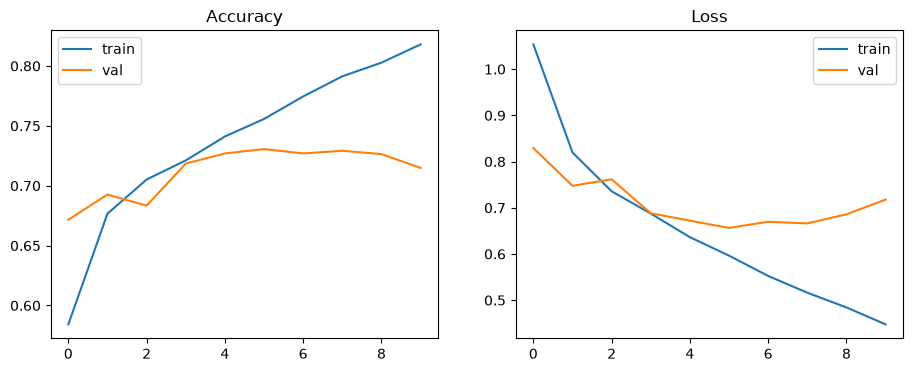

In [15]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

        nino       0.94      0.89      0.92       512
 adolescente       0.39      0.46      0.42       177
       joven       0.78      0.81      0.79      1577
      adulto       0.61      0.62      0.62       887
       viejo       0.79      0.60      0.68       403

    accuracy                           0.73      3556
   macro avg       0.70      0.68      0.69      3556
weighted avg       0.74      0.73      0.74      3556



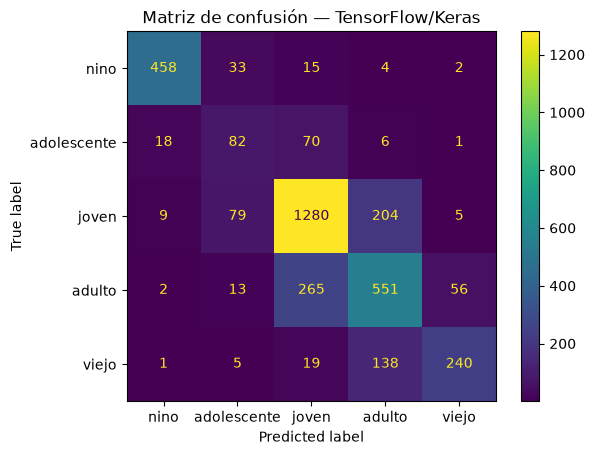

In [16]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — TensorFlow/Keras")
plt.show()

### Curva ROC — TensorFlow/Keras

Misma lectura que la ROC de PyTorch, ahora para el modelo de Keras. Sirve para comparar la capacidad de separación de ambos frameworks clase por clase.

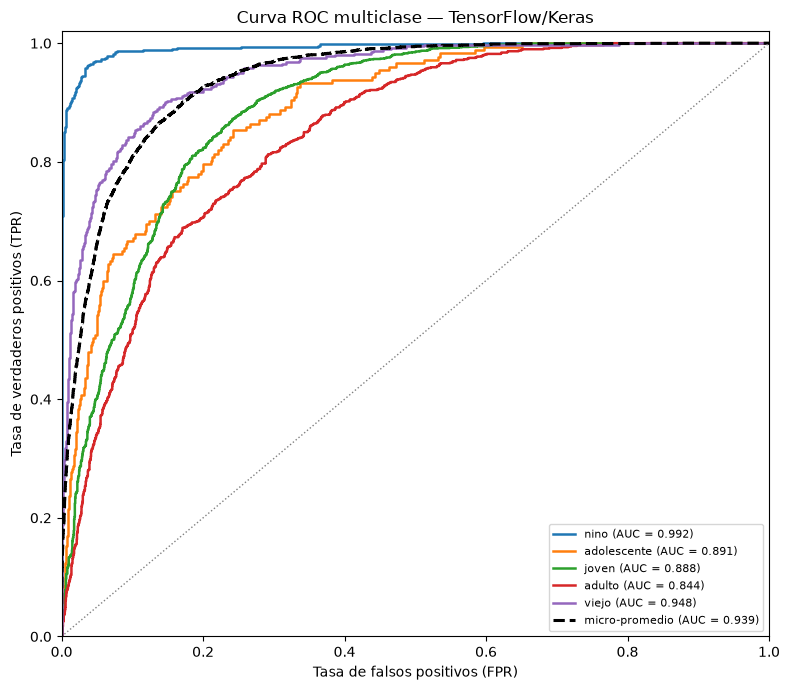

In [17]:
# --- Curva ROC (Keras) ---
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# El modelo de Keras ya entrega softmax en su capa final.
probs_tf, y_roc_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    probs_tf.extend(preds)
    y_roc_tf.extend(labels.numpy())
probs_tf = np.array(probs_tf)
y_roc_tf = np.array(y_roc_tf)

n_classes = len(CLASS_NAMES)
y_bin = label_binarize(y_roc_tf, classes=list(range(n_classes)))

plt.figure(figsize=(8, 7))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs_tf[:, i])
    plt.plot(fpr, tpr, lw=1.8, label=f"{CLASS_NAMES[i]} (AUC = {auc(fpr, tpr):.3f})")

fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), probs_tf.ravel())
plt.plot(fpr_micro, tpr_micro, "k--", lw=2.2,
         label=f"micro-promedio (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlim([0, 1]); plt.ylim([0, 1.02])
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC multiclase — TensorFlow/Keras")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## Comparación final

Los dos frameworks quedaron muy parejos: PyTorch alcanzó alrededor de 0.74 de accuracy en validación y Keras cerca de 0.72, con los mismos datos. Las clases que más se confunden son 'adolescente' y 'viejo', que son justo las que menos imágenes tienen en este banco desbalanceado, y se van sobre todo hacia 'joven' y 'adulto'.  
**Para mejorar, lo primero sería balancear las clases, que es lo que haremos en el siguiente notebook.**


## Prueba

Se harán pruebas con fotos propias y algunas fotos sacadas del dataset. Estas están en la carpeta fotos_prueba.

Fotos encontradas: 16


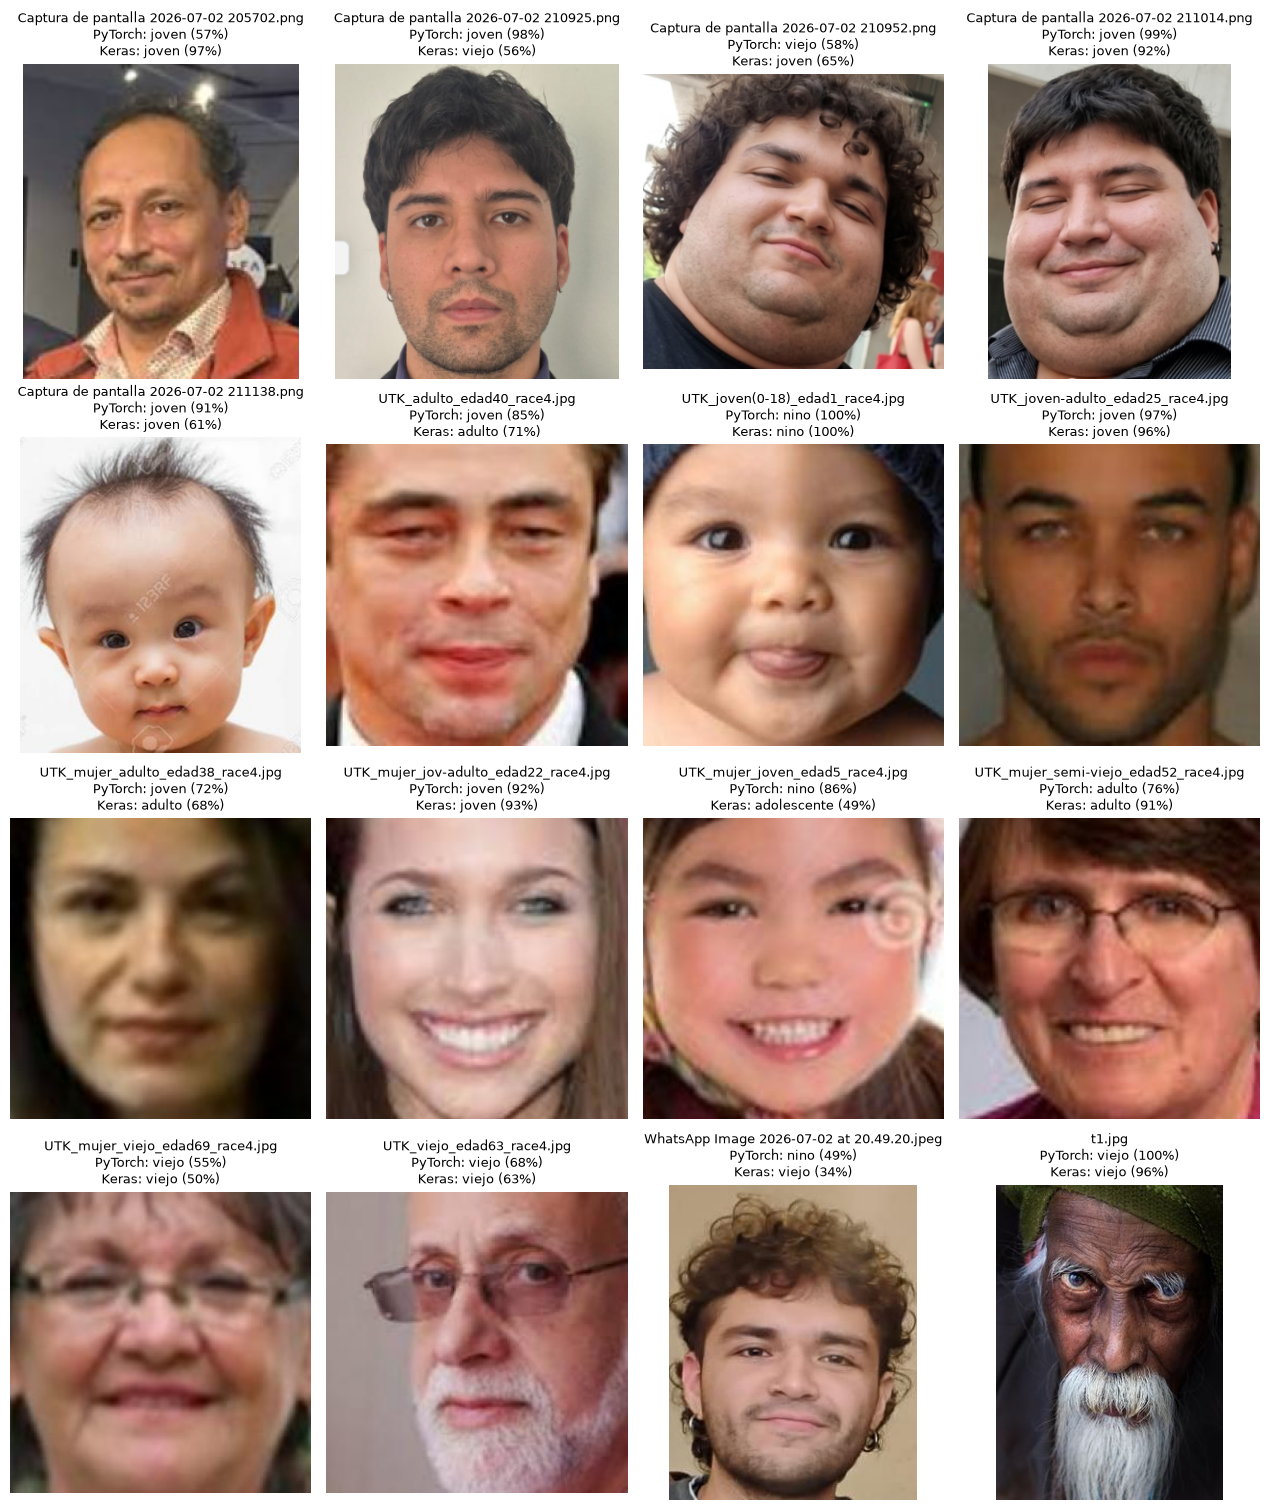

In [18]:
# --- Prueba con imágenes propias ---
# 1) Deja tus fotos (una cara por imagen) en la carpeta FOTOS_PRUEBA.
# 2) Ejecuta esta celda DESPUÉS de haber entrenado los modelos más arriba.
import glob
from PIL import Image

FOTOS_PRUEBA = "./fotos_prueba"   # <-- carpeta con tus imágenes de prueba

exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
rutas = []
for e in exts:
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e))
    rutas += glob.glob(os.path.join(FOTOS_PRUEBA, e.upper()))
rutas = sorted(set(rutas))

if len(rutas) == 0:
    raise FileNotFoundError(
        f"No encontré imágenes en '{FOTOS_PRUEBA}'. Crea la carpeta y deja adentro "
        "algunas fotos (jpg o png), con una cara por imagen."
    )
print(f"Fotos encontradas: {len(rutas)}")

tiene_pt = "model_pt" in globals()   # modelo PyTorch entrenado
tiene_tf = "model_tf" in globals()   # modelo Keras entrenado

def predecir_pytorch(img_pil):
    model_pt.eval()
    x = transform(img_pil).unsqueeze(0).to(device)   # mismo preprocesamiento del entrenamiento
    with torch.no_grad():
        probs = torch.softmax(model_pt(x), dim=1)[0].cpu().numpy()
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

def predecir_keras(img_pil):
    arr = np.asarray(img_pil.resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
    probs = model_tf.predict(arr[None, ...], verbose=0)[0]
    idx = int(probs.argmax())
    return CLASS_NAMES[idx], float(probs[idx])

# Muestra las fotos en una grilla con la predicción de cada modelo
n = len(rutas)
cols = min(4, n)
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.8))
axes = np.array(axes).reshape(-1)

for ax, ruta in zip(axes, rutas):
    img = Image.open(ruta).convert("RGB")
    lineas = [os.path.basename(ruta)]
    if tiene_pt:
        lab, p = predecir_pytorch(img)
        lineas.append(f"PyTorch: {lab} ({p*100:.0f}%)")
    if tiene_tf:
        lab, p = predecir_keras(img)
        lineas.append(f"Keras: {lab} ({p*100:.0f}%)")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("\n".join(lineas), fontsize=9)

for ax in axes[n:]:   # apaga los recuadros que sobran en la grilla
    ax.axis("off")

plt.tight_layout()
plt.show()
